In [1]:
# DO THIS ONCE ONLY!!!
!wget https://streamstats.usgs.gov/streamgrids/nj/nj.zip
!unzip nj.zip -d nj

--2025-05-29 21:40:24--  https://streamstats.usgs.gov/streamgrids/nj/nj.zip
Resolving streamstats.usgs.gov (streamstats.usgs.gov)... 54.221.69.48, 34.194.158.25
Connecting to streamstats.usgs.gov (streamstats.usgs.gov)|54.221.69.48|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31471299 (30M) [application/zip]
Saving to: ‘nj.zip.1’

nj.zip.1            100%[===================>]  30.01M  65.4MB/s    in 0.5s    

2025-05-29 21:40:25 (65.4 MB/s) - ‘nj.zip.1’ saved [31471299/31471299]

Archive:  nj.zip
  inflating: nj/excludepolys.cpg     
  inflating: nj/excludepolys.dbf     
  inflating: nj/excludepolys.prj     
  inflating: nj/excludepolys.sbn     
  inflating: nj/excludepolys.sbx     
  inflating: nj/excludepolys.shp     
  inflating: nj/excludepolys.shp.xml  
  inflating: nj/excludepolys.shx     
  inflating: nj/ReadMe.txt           
  inflating: nj/streamgrid.tfw       
  inflating: nj/streamgrid.tif       
  inflating: nj/streamgrid.tif.aux.xml  
  inflat

# Import libs

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
from io import StringIO
from datetime import datetime
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Iterable, Optional, Union
import itertools, math, time, json, pathlib
from tenacity import retry, wait_fixed, stop_after_attempt
from pathlib import Path
import time
from dbfread import DBF
import geopandas
import os
from shapely.geometry import Point # For creating point geometries
from shapely.ops import nearest_points # For vector fallback or other uses (now correctly importable)
import rasterio
from rasterio.warp import transform_geom # For CRS transformations
import streamstats
import dataretrieval.nwis as nwis

# Utility functions

In [2]:
from requests import HTTPError, ReadTimeout


def remove_outliers(
    df: pd.DataFrame,
    cols: Optional[Union[str, Iterable[str]]] = None,
    lower_pct: float = 0.5,
    upper_pct: float = 99.5,
    inplace: bool = False,
) -> pd.DataFrame:
    """
    Replace values below the lower percentile or above the
    upper percentile with those exact percentile values ("closest bounds").

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    cols : str | Iterable[str] | None, optional
        Column or collection of columns to winsorize.  
        • If *None* (default), all numeric columns are processed.  
        • Non-numeric columns are ignored silently.
    lower_pct : float, optional
        Lower percentile (0-100) that defines the lower bound. Default 0.5.
    upper_pct : float, optional
        Upper percentile (0-100) that defines the upper bound. Default 99.5.
    inplace : bool, optional

    Returns
    -------
    pd.DataFrame
    """
    if lower_pct < 0 or upper_pct > 100 or lower_pct >= upper_pct:
        raise ValueError("Percentiles must satisfy 0 ≤ lower < upper ≤ 100.")

    if cols is None:
        # Select only numeric columns to avoid accidental dtype issues
        cols = df.select_dtypes(include="number").columns
    elif isinstance(cols, str):
        cols = [cols]

    working_df = df if inplace else df.copy()

    lo_q = lower_pct / 100.0
    hi_q = upper_pct / 100.0

    for col in cols:
        if col not in working_df.columns or not pd.api.types.is_numeric_dtype(
            working_df[col]
        ):
            # Skip silently for non‑existing or non‑numeric columns
            continue

        # Calculate the percentile bounds
        lower_bound, upper_bound = working_df[col].quantile([lo_q, hi_q]).values

        #drop anything outside [lower_bound, upper_bound] to the bound
        working_df[col] = working_df[col].clip(lower=lower_bound, upper=upper_bound)

    return working_df

def percentile_band_min_max(
    df: pd.DataFrame,
    col: str,
    step: float = 1.0,
):
    if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
        raise ValueError(f"Column {col!r} is missing or not numeric.")

    if step <= 0 or step > 100:
        raise ValueError("step must be in (0, 100].")

    data = df[col]
    # Build percentile cut‑points 0, step, 2*step, …, 100
    edges = np.arange(0, 100 + step, step)

    # duplicates='drop' avoids errors if there are repeated quantile values
    bands = pd.qcut(data, q=edges / 100.0, labels=False, duplicates="drop")

    grouped = data.groupby(bands).agg(min="min", max="max")

    # Add readable percentile bounds
    grouped["p_low"] = grouped.index * step
    grouped["p_high"] = grouped["p_low"] + step
    grouped = grouped[["p_low", "p_high", "min", "max"]].reset_index(drop=True)

    return grouped

# --- Configuration ---
NJ_STREAM_GRID_TIF = "nj/streamgrid.tif" 
OUTPUT_CSV_PATH = "data/basin_characteristics_snapped.csv"
TIMEOUT = 360  # Timeout for requests in seconds

def snap_coordinates_to_raster_stream(sites_df, stream_raster_path, 
                                             search_radius_pixels=5, stream_value=1):
    """
    Snaps site coordinates to the nearest stream pixel in a GeoTIFF raster.
    If snapping fails (no stream pixel found or point outside extent), 
    it falls back to using the original WGS84 coordinates.

    Args:
        sites_df (pd.DataFrame): DataFrame with 'site_no', 'lat', 'lon' (WGS84).
        stream_raster_path (str): Path to the stream grid GeoTIFF file.
        search_radius_pixels (int): How many pixels around initial point to search.
        stream_value (int or float): The pixel value in the raster that represents a stream.
                                     *** CRITICAL: VERIFY THIS VALUE FOR YOUR TIFF ***
    Returns:
        pd.DataFrame: DataFrame with 'snapped_lat', 'snapped_lon', 'snapping_error'.
                      Snapped coordinates will be original if snapping failed.
    """
    print(f"Loading stream grid raster from: {stream_raster_path}")
    print(f"*** Using stream_value={stream_value} and search_radius_pixels={search_radius_pixels} ***")

    # Initialize output columns with original coordinates as default/fallback
    snapped_lats_final = sites_df['lat'].copy()
    snapped_lons_final = sites_df['lon'].copy()
    snapping_errors = pd.Series([None] * len(sites_df), index=sites_df.index, dtype=object)


    try:
        with rasterio.open(stream_raster_path) as src:
            raster_crs = src.crs
            # raster_transform = src.transform # Affine transformation
            raster_band = src.read(1) 
            height, width = raster_band.shape

            if not raster_crs:
                snapping_errors[:] = "Raster CRS missing, cannot snap. Using original coordinates for all."
                print("ERROR: Raster file is missing Coordinate Reference System (CRS).")
                # Prepare output DataFrame and return
                output_df = sites_df.copy()
                output_df['snapped_lat'] = snapped_lats_final
                output_df['snapped_lon'] = snapped_lons_final
                output_df['snapping_error'] = snapping_errors
                return output_df

            print(f"Raster CRS: {raster_crs}, Dimensions: {width}x{height}. Input points WGS84 (EPSG:4326).")

            for i, row in sites_df.iterrows(): # Use i for iloc access if needed, or index for loc
                site_lat, site_lon = row['lat'], row['lon']
                current_site_error = f"Snapping failed (no stream pixel found with value {stream_value} within {search_radius_pixels}px radius), using original coordinates."
                successfully_snapped_this_point = False

                if pd.isna(site_lat) or pd.isna(site_lon):
                    snapping_errors.loc[i] = "Missing original coordinates, cannot snap."
                    # snapped_lats_final.loc[i] and snapped_lons_final.loc[i] already hold NaN from original
                    continue

                try:
                    # 1. Transform site coordinates from WGS84 to raster CRS
                    geom_wgs84 = {'type': 'Point', 'coordinates': (site_lon, site_lat)}
                    geom_raster_crs = transform_geom('EPSG:4326', raster_crs, geom_wgs84, antimeridian_cutting=True)
                    raster_x_orig, raster_y_orig = geom_raster_crs['coordinates']

                    # 2. Get pixel indices from transformed coordinates
                    try:
                        py_orig, px_orig = src.index(raster_x_orig, raster_y_orig) # row, col
                    except IndexError: # Point is outside the data cells of the raster
                        current_site_error = "Original point outside raster data cells (src.index failed), using original coordinates."
                        # Fallback to original coords is already default, just set error and continue
                        snapping_errors.loc[i] = current_site_error
                        continue 
                    
                    # 3. Check if calculated pixel indices are within raster dimensions
                    if not (0 <= py_orig < height and 0 <= px_orig < width):
                        current_site_error = f"Original point's calculated pixel index (R:{py_orig},C:{px_orig}) is outside raster dimensions (H:{height},W:{width}), using original coordinates."
                        snapping_errors.loc[i] = current_site_error
                        continue

                    # 4. Direct Hit Check: Is the point directly on a stream pixel?
                    if raster_band[py_orig, px_orig] == stream_value:
                        center_lon_raster, center_lat_raster = src.xy(py_orig + 0.5, px_orig + 0.5)
                        geom_snapped_raster = {'type': 'Point', 'coordinates': (center_lon_raster, center_lat_raster)}
                        geom_snapped_wgs84 = transform_geom(raster_crs, 'EPSG:4326', geom_snapped_raster, antimeridian_cutting=True)
                        
                        snapped_lats_final.loc[i] = geom_snapped_wgs84['coordinates'][1]
                        snapped_lons_final.loc[i] = geom_snapped_wgs84['coordinates'][0]
                        snapping_errors.loc[i] = "Snapped directly to stream pixel."
                        successfully_snapped_this_point = True
                    
                    # 5. Search Nearby (if no direct hit)
                    if not successfully_snapped_this_point:
                        min_dist_sq = float('inf')
                        found_in_search = False
                        temp_snap_lat, temp_snap_lon = np.nan, np.nan

                        for r_offset in range(-search_radius_pixels, search_radius_pixels + 1):
                            for c_offset in range(-search_radius_pixels, search_radius_pixels + 1):
                                if r_offset == 0 and c_offset == 0: # Already checked (direct hit)
                                    continue 
                                
                                search_py, search_px = py_orig + r_offset, px_orig + c_offset
                                if 0 <= search_py < height and 0 <= search_px < width:
                                    if raster_band[search_py, search_px] == stream_value:
                                        dist_sq = r_offset**2 + c_offset**2
                                        if dist_sq < min_dist_sq:
                                            min_dist_sq = dist_sq
                                            center_lon_s_raster, center_lat_s_raster = src.xy(search_py + 0.5, search_px + 0.5)
                                            geom_s_raster = {'type': 'Point', 'coordinates': (center_lon_s_raster, center_lat_s_raster)}
                                            geom_s_wgs84 = transform_geom(raster_crs, 'EPSG:4326', geom_s_raster, antimeridian_cutting=True)
                                            temp_snap_lat = geom_s_wgs84['coordinates'][1]
                                            temp_snap_lon = geom_s_wgs84['coordinates'][0]
                                            found_in_search = True
                        
                        if found_in_search:
                            snapped_lats_final.loc[i] = temp_snap_lat
                            snapped_lons_final.loc[i] = temp_snap_lon
                            snapping_errors.loc[i] = f"Snapped to stream pixel within {search_radius_pixels}px radius."
                            successfully_snapped_this_point = True
                    
                    # If still not snapped, the default error message and original coords remain
                    if not successfully_snapped_this_point:
                        snapping_errors.loc[i] = current_site_error # Error for this site

                except Exception as e_snap_single:
                    snapping_errors.loc[i] = f"Error during snapping for site {row['site_no']}: {type(e_snap_single).__name__} - {e_snap_single}. Using original coordinates."
                    # Fallback to original coords is already default
                    
    except FileNotFoundError:
        print(f"ERROR: Stream grid raster file not found at '{stream_raster_path}'.")
        snapping_errors[:] = "Stream grid raster file not found. Using original coordinates for all."
    except Exception as e_raster_open:
        print(f"ERROR: Failed to open or process stream grid raster: {e_raster_open}")
        snapping_errors[:] = f"Raster processing error ({type(e_raster_open).__name__}). Using original coordinates for all."

    # Construct the output DataFrame
    output_df = sites_df.copy() # Start with original structure
    output_df['snapped_lat'] = snapped_lats_final
    output_df['snapped_lon'] = snapped_lons_final
    output_df['snapping_error'] = snapping_errors
    
    print("Raster snapping complete.")
    return output_df

def get_nj_sites():
    url = "https://waterservices.usgs.gov/nwis/site/"
    params = {
        "stateCd": "NJ",
        "format" : "rdb",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()

    # strip comment lines and load as tab-delimited text
    clean = "\n".join(ln for ln in r.text.splitlines() if not ln.startswith("#"))
    df = pd.read_csv(io.StringIO(clean), sep=r"\t", dtype=str)

    df = df[df["agency_cd"] == "USGS"].copy()
    df["lat"] = df["dec_lat_va"].astype(float)
    df["lon"] = df["dec_long_va"].astype(float)
    return df[["site_no", "lat", "lon"]]

def get_site_coordinates(site_numbers):
    """
    Retrieves latitude and longitude for a list of USGS site numbers.
    """
    site_info_list = []
    for site_no in site_numbers:
        site_no = str(site_no)
        try:
            site_data_df = nwis.get_record(sites=site_no, service='site')

            if not site_data_df.empty:
                # Check for common latitude and longitude column names
                lat_col_names = ['dec_lat_va', 'latitude', 'lat_va']
                lon_col_names = ['dec_long_va', 'longitude', 'lon_va']

                lat = None
                lon = None

                for col in lat_col_names:
                    if col in site_data_df.columns:
                        lat = site_data_df[col].iloc[0]
                        break
                
                for col in lon_col_names:
                    if col in site_data_df.columns:
                        lon = site_data_df[col].iloc[0]
                        break
                
                if lat is not None and lon is not None:
                    site_info_list.append({'site_no': site_no, 'latitude': lat, 'longitude': lon})
                else:
                    print(f"Warning: Could not find lat/lon columns for site {site_no} in columns: {site_data_df.columns.tolist()}")
                    site_info_list.append({'site_no': site_no, 'latitude': None, 'longitude': None})
            else:
                print(f"Warning: Could not retrieve information for site {site_no}")
                site_info_list.append({'site_no': site_no, 'latitude': None, 'longitude': None})
        except Exception as e:
            print(f"Error retrieving info for site {site_no}: {e}")
            site_info_list.append({'site_no': site_no, 'latitude': None, 'longitude': None})
    return pd.DataFrame(site_info_list)



# Core functions

In [3]:
def retrieve_usgs_timeseries(stateCd: str,
                             parameterCd: str,
                             var_name: str,
                             startDT: str,
                             endDT: str,
                             out_csv: str):
    """
    Download a USGS DV time series for a single parameter, clean it, and save as CSV.
    """
    url = (
        f"https://waterservices.usgs.gov/nwis/dv/?format=json"
        f"&stateCd={stateCd}"
        f"&parameterCd={parameterCd}"
        f"&startDT={startDT}"
        f"&endDT={endDT}"
    )
    r = requests.get(url)
    if r.status_code != 200:
        raise RuntimeError(f"Error {r.status_code} retrieving {var_name} ({parameterCd})")
    js = r.json()
    json.dump(js, open(f"../tmp/usgs_{var_name}.json", "w"), indent=2)
    
    rows = []
    if len(js.get("value", {}).get("timeSeries", [])) == 0:
        raise RuntimeError(f"No time series found for {var_name} ({parameterCd})")
    
    
    for ts in js.get("value", {}).get("timeSeries", []):
        src = ts["sourceInfo"]
        site_name = src["siteName"]
        site_code = src["siteCode"][0]["value"]
        for meas in ts.get("values", []):
            for rec in meas.get("value", []):
                rows.append({
                    "siteCode":    site_code,
                    "siteName":    site_name,
                    "variable":    var_name,
                    "dateTime":    rec["dateTime"][:10],
                    "value":       float(rec["value"]) if rec["value"] not in (None,"") else pd.NA
                })
    df = pd.DataFrame(rows)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    df = remove_outliers(df, "value", 0.5, 99.5, inplace=False)
    
    df.to_csv(out_csv, index=False)
    print(f"Saved {var_name} to {out_csv}")
    return df


def get_basin_characteristics(snapped_sites_df, output_csv_path):
    """
    Retrieves basin characteristics for sites using their SNAPPED coordinates
    and the streamstats-python library.
    Collects all data in memory before writing to CSV.
    """
    processed_site_nos_from_file = set()

    if os.path.exists(output_csv_path):
        print(f"Output file found: '{output_csv_path}'. Loading previously processed sites.")
        try:
            temp_existing_df = pd.read_csv(output_csv_path, dtype={'site_no': str}, low_memory=False)
            if not temp_existing_df.empty and 'site_no' in temp_existing_df.columns:
                processed_site_nos_from_file = set(temp_existing_df['site_no'].astype(str).tolist())
                print(f"Loaded {len(processed_site_nos_from_file)} site IDs from the existing file. These will be skipped.")
        except pd.errors.ParserError as pe:
            print(f"ParserError reading existing CSV '{output_csv_path}': {pe}. File might be malformed from previous runs.")
            print("Consider backing up and deleting the old CSV if errors persist, or manually fixing it.")
        except Exception as e:
            print(f"Error reading existing output file '{output_csv_path}': {e}.")

    newly_processed_data_list = [] 

    print(f"\nStarting processing for {len(snapped_sites_df)} sites provided...")
    for index, row in snapped_sites_df.iterrows():
        site_no = str(row['site_no'])
        original_lat = row['lat']
        original_lon = row['lon']
        lat = row['snapped_lat'] 
        lon = row['snapped_lon'] 
        snapping_err = row.get('snapping_error') 

        if site_no in processed_site_nos_from_file:
            continue

        print(f"\nProcessing new site: {site_no} (Original: {original_lat},{original_lon} -> Snapped: {lat},{lon})")
        
        # Initialize with basic info for this site
        current_site_data = {
            'site_no': site_no, 
            'original_lat': original_lat, 
            'original_lon': original_lon,
            'snapped_lat': lat,
            'snapped_lon': lon,
            'snapping_error': snapping_err if pd.notna(snapping_err) else np.nan,
            'streamstats_error': np.nan # Initialize
        }

        if pd.isna(lat) or pd.isna(lon):
            msg = f"Site {site_no} has missing snapped coordinates."
            if snapping_err and pd.notna(snapping_err):
                msg += f" Snapping error: {snapping_err}"
            else:
                msg += " Snapping error: (No specific snapping error message, likely due to missing original coords or failed raster processing)"
            print(f"  {msg}")
            current_site_data['streamstats_error'] = msg
            newly_processed_data_list.append(current_site_data)
            continue 

        try:
            print(f"  Calling StreamStats API for site {site_no} with snapped coords: Lat={lat}, Lon={lon}")
            ws = streamstats.Watershed(lat=lat, lon=lon)
            available_char_codes = ws.characteristics
            print(f"  Retrieved {len(available_char_codes)} characteristic codes for site {site_no}.")
            if not available_char_codes:
                print(f"  No characteristics codes returned by ws.characteristics for site {site_no}.")
                current_site_data['streamstats_error'] = 'No characteristic codes available from API'
            else:
                print(f"  Found {len(available_char_codes)} characteristic codes for site {site_no}.")
                for char_code in available_char_codes:
                    if not char_code: continue
                    try:
                        char_data = ws.get_characteristic(char_code)
                        char_value = char_data.get('value')
                        current_site_data[char_code] = char_value # Add characteristic to current site's dict
                    except Exception as char_e:
                        print(f"    Could not retrieve value for characteristic '{char_code}': {char_e}")
                        current_site_data[char_code] = np.nan
                        s_error = current_site_data.get('streamstats_error', '')
                        if pd.isna(s_error): s_error = ''
                        if s_error and not s_error.endswith('; '): s_error += '; '
                        current_site_data['streamstats_error'] = s_error + f"Failed to get {char_code}"
        except Exception as e:
            print(f"  Error processing site {site_no} with StreamStats library: {e}")
            if "point not in any state" in str(e).lower() or \
               "no stream cell" in str(e).lower() or \
               "delineation failed" in str(e).lower() or \
               "point not in service area" in str(e).lower():
                current_site_data['streamstats_error'] = f"API Error: {e} (Likely off-stream, outside service area, or snapping insufficient)"
            else:
                current_site_data['streamstats_error'] = str(e)
        
        newly_processed_data_list.append(current_site_data)
        time.sleep(1.1)

    print("\nProcessing complete for all new sites.")

    final_df_to_write = pd.DataFrame()

    # Load existing data again, this time with intention to merge/concat
    # This is a bit complex if the old file is malformed.
    # A simpler approach for this fix: if old file exists, append new, then de-duplicate.
    # Better: if old file exists and is readable, load it. Then concat with new.

    if os.path.exists(output_csv_path):
        try:
            existing_df = pd.read_csv(output_csv_path, dtype={'site_no': str}, low_memory=False)
            print(f"Successfully loaded existing data from '{output_csv_path}' for merging.")
        except pd.errors.ParserError as pe:
            print(f"WARNING: ParserError when re-reading '{output_csv_path}' for final merge: {pe}.")
            print("The CSV might have been malformed. Will attempt to use only newly processed data for this write.")
            existing_df = pd.DataFrame() # Fallback to empty if unreadable
        except Exception as e:
            print(f"WARNING: Could not re-read '{output_csv_path}' for final merge: {e}.")
            existing_df = pd.DataFrame() # Fallback
    else:
        existing_df = pd.DataFrame()

    if newly_processed_data_list:
        new_data_df = pd.DataFrame(newly_processed_data_list)
        # Concatenate new data with existing data
        final_df_to_write = pd.concat([existing_df, new_data_df], ignore_index=True)
        print(f"Added {len(new_data_df)} newly processed sites to the dataset.")
    elif not existing_df.empty:
        final_df_to_write = existing_df # No new data, just write back old data (potentially with deduplication)
        print("No new sites processed in this run. Working with existing data.")
    else:
        print("No existing data and no new sites processed. Output will be empty or not written.")
        return pd.DataFrame()


    if not final_df_to_write.empty:
        # Ensure site_no is the first column for readability if it exists
        if 'site_no' in final_df_to_write.columns:
            cols = final_df_to_write.columns.tolist()
            if 'site_no' in cols: # Should always be true if data exists
                cols.insert(0, cols.pop(cols.index('site_no')))
                final_df_to_write = final_df_to_write.loc[:, cols]
            # De-duplicate based on site_no, keeping the latest entry
            final_df_to_write.drop_duplicates(subset=['site_no'], keep='last', inplace=True)
        
        try:
            final_df_to_write.to_csv(output_csv_path, index=False)
            print(f"Successfully wrote/updated '{output_csv_path}' with {len(final_df_to_write)} unique sites.")
        except Exception as e_save:
            print(f"  CRITICAL: Failed to write final consolidated data to CSV '{output_csv_path}': {e_save}")
    else:
        print("No data to write to CSV.")
        
    return final_df_to_write

# Action

In [14]:
params = {
    "00060": "discharge",             # discharge 
    "00193": "total_precipitation",           # total precipitation (inches)
    "00045": "precipitation",           # precipitation (inches)
    "00010": "water_temp_celsius",     # water temp
    "00011": "water_temp_fahrenheit",     # water temp
    "00012": "evaporation_temp_48",          # 48-inch pan
    "00013": "evaporation_temp_24",          # 24-inch pan
    "00020": "air_temp_celsius",     # air temp
    "00021": "air_temp_fahrenheit",     # air temp
    "00030": "solar_radiation",    # solar radiation
    "00032": "cloud_cover",      # cloud cover
    "00035": "wind_speed",      # wind speed
    "00050": "evaporation_rate",      # evaporation rate
    "00052": "relative_humidity",      # relative humidity
    "00064": "mean_stream_depth"
}

# example date range
start, end = "2020-01-01", "2024-12-31"

# loop and pull each variable
for code, name in params.items():
    out_csv = f"data/usgs_{name}.csv"
    try:
        retrieve_usgs_timeseries(
            stateCd="NJ",
            parameterCd=code,
            var_name=name,
            startDT=start,
            endDT=end,
            out_csv=out_csv
        )
    except RuntimeError as e:
        print(f"Error retrieving {name}: {e}")

Saved discharge to data/usgs_discharge.csv
Error retrieving total_precipitation: No time series found for total_precipitation (00193)
Saved precipitation to data/usgs_precipitation.csv
Saved water_temp_celsius to data/usgs_water_temp_celsius.csv
Error retrieving water_temp_fahrenheit: No time series found for water_temp_fahrenheit (00011)
Error retrieving evaporation_temp_48: No time series found for evaporation_temp_48 (00012)
Error retrieving evaporation_temp_24: No time series found for evaporation_temp_24 (00013)
Saved air_temp_celsius to data/usgs_air_temp_celsius.csv
Error retrieving air_temp_fahrenheit: No time series found for air_temp_fahrenheit (00021)
Error retrieving solar_radiation: No time series found for solar_radiation (00030)
Error retrieving cloud_cover: No time series found for cloud_cover (00032)
Error retrieving wind_speed: No time series found for wind_speed (00035)
Error retrieving evaporation_rate: No time series found for evaporation_rate (00050)
Error retriev

In [ ]:
var_files = {
    "discharge"      : "data/usgs_discharge.csv",
    "precipitation"         : "data/usgs_precipitation.csv",
    "air_temp_celsius"      : "data/usgs_air_temp_celsius.csv",
    "water_temp_celsius"      : "data/usgs_water_temp_celsius.csv",
}

# Read each file, store the DataFrame in a dict keyed by variable name
var_dfs = {name: pd.read_csv(path) for name, path in var_files.items()}

for name, df in var_dfs.items():
    summary = percentile_band_min_max(df, "value", step=1.0)
    print(f"Summary for {name}:")
    print(summary)
    print(f"Describe for {name}:")
    print(df.describe())
    print(f"Null count for {name}:")
    print(df.isna().sum())

Summary for discharge:
    p_low  p_high       min       max
0     0.0     1.0      0.24      0.61
1     1.0     2.0      0.62      1.15
2     2.0     3.0      1.16      1.57
3     3.0     4.0      1.58      1.98
4     4.0     5.0      1.99      2.51
..    ...     ...       ...       ...
95   95.0    96.0    958.00   1440.00
96   96.0    97.0   1450.00   2680.00
97   97.0    98.0   2690.00   5650.00
98   98.0    99.0   5660.00  11000.00
99   99.0   100.0  11100.00  15800.00

[100 rows x 4 columns]
Describe for discharge:
           siteCode          value
count  2.100050e+05  210005.000000
mean   2.625465e+06     379.497960
std    1.321587e+07    1708.006721
min    1.377000e+06       0.240000
25%    1.389500e+06      13.600000
50%    1.403400e+06      38.300000
75%    1.443280e+06     120.000000
max    1.465873e+08   15800.000000
Null count for discharge:
siteCode    0
siteName    0
variable    0
dateTime    0
value       0
dtype: int64
Summary for precipitation:
    p_low  p_high   mi

# GET SITE STATIC ATTRIBUTES

In [7]:
print("Loading site data from local CSVs...")
try:
    # Ensure your CSV loading results in a DataFrame 'initial_sites_df'
    # with 'site_no', 'lat', 'lon' columns containing numeric lat/lon.
    df_sites_csv = pd.read_csv("data/usgs_nj_sites.csv", dtype={'site_no': str, 'lat': str, 'lon': str})
    df_discharge_csv = pd.read_csv("data/usgs_discharge.csv", dtype={'siteCode': str})
    
    # Ensure site_no types match for merging
    df_sites_csv['site_no'] = df_sites_csv['site_no'].str.strip()
    df_discharge_csv['siteCode'] = df_discharge_csv['siteCode'].str.strip()

    df_merge_csv = df_discharge_csv.merge(df_sites_csv, left_on="siteCode", right_on="site_no", how="left")
    
    initial_sites_df = df_merge_csv[["site_no", "lat", "lon"]].copy() # Use .copy()
    initial_sites_df.dropna(subset=['site_no'], inplace=True) # Ensure site_no is present
    initial_sites_df = initial_sites_df.drop_duplicates(subset=['site_no'])
    
    initial_sites_df['lat'] = pd.to_numeric(initial_sites_df['lat'], errors='coerce')
    initial_sites_df['lon'] = pd.to_numeric(initial_sites_df['lon'], errors='coerce')
    initial_sites_df.dropna(subset=['lat', 'lon'], inplace=True)
    
    print(f"Loaded {len(initial_sites_df)} unique sites with coordinates from CSVs.")
except Exception as e:
    print(f"Error loading sites from local CSV: {e}")
    initial_sites_df = pd.DataFrame()

if not initial_sites_df.empty:
    if not os.path.exists(NJ_STREAM_GRID_TIF):
        print(f"ERROR: Stream grid raster file not found at '{NJ_STREAM_GRID_TIF}'.")
        print("Please download it, place it correctly, and update the NJ_STREAM_GRID_TIF variable.")
        snapped_sites_df = initial_sites_df.copy()
        snapped_sites_df['snapped_lat'] = np.nan
        snapped_sites_df['snapped_lon'] = np.nan
        snapped_sites_df['snapping_error'] = 'Stream grid TIF file missing'
    else:
        snapped_sites_df = snap_coordinates_to_raster_stream(initial_sites_df, NJ_STREAM_GRID_TIF, stream_value=1, search_radius_pixels=10)
    
    print("\nSample of original vs. snapped coordinates:")
    print(snapped_sites_df[['site_no', 'lat', 'lon', 'snapped_lat', 'snapped_lon', 'snapping_error']])

    basin_characteristics_df = get_basin_characteristics(snapped_sites_df, OUTPUT_CSV_PATH)
    
    print("\nFinal Basin Characteristics Data (sample from CSV):")
    if not basin_characteristics_df.empty:
        print(basin_characteristics_df.head())
    else:
        print("No basin characteristics data was processed or returned.")
else:
    print("No initial site coordinates to process.")

Loading site data from local CSVs...


Loaded 119 unique sites with coordinates from CSVs.
Loading stream grid raster from: nj/streamgrid.tif
*** Using stream_value=1 and search_radius_pixels=10 ***
Raster CRS: EPSG:3424, Dimensions: 48603x116082. Input points WGS84 (EPSG:4326).
Raster snapping complete.

Sample of original vs. snapped coordinates:
         site_no        lat        lon  snapped_lat  snapped_lon  \
0       01377000  40.999167 -73.989167    40.999125   -73.989203   
1827    01377370  41.036667 -74.039167    41.036667   -74.039167   
3654    01377500  40.992778 -74.021111    40.992922   -74.021167   
5481    01378500  40.948333 -74.026667    40.948333   -74.026667   
7308    01379000  40.680000 -74.528889    40.679998   -74.528720   
...          ...        ...        ...          ...          ...   
200891  01467150  39.903056 -75.021389    39.902971   -75.021527   
202718  01475001  39.738889 -75.114444    39.738862   -75.114420   
204545  01477070  39.686111 -75.184444    39.685865   -75.184699   
206343  

In [6]:
ws = streamstats.Watershed(lat=40.679998, lon=-74.528720)
available_char_codes = ws.characteristics

In [ ]:
from requests import RequestException


ESSENTIAL_CHARACTERISTICS = ['DRNAREA'] # Drainage Area is a common one

# Retry mechanism parameters for StreamStats API calls
MAX_API_RETRIES = 3
INITIAL_RETRY_DELAY_SECONDS = 5 # e.g., 5, 10, 20 seconds for retries

def reprocess_site_characteristics(site_data_row):
    """
    Attempts to fetch basin characteristics for a single site.

    Args:
        site_data_row (pd.Series): A row from the DataFrame representing a single site.
                                   Expected to have 'site_no', 
                                   'original_lat', 'original_lon',
                                   'snapped_lat', 'snapped_lon'.

    Returns:
        dict: A dictionary containing the site_no and fetched characteristics,
              along with 'streamstats_error_reprocessed'.
              If successful, 'streamstats_error_reprocessed' will be None or a success message.
    """
    site_no = str(site_data_row['site_no'])
    
    # Determine coordinates to use
    lat_to_use, lon_to_use = np.nan, np.nan
    coord_source = "unknown"

    if pd.notna(site_data_row.get('snapped_lat')) and pd.notna(site_data_row.get('snapped_lon')):
        lat_to_use = site_data_row['snapped_lat']
        lon_to_use = site_data_row['snapped_lon']
        coord_source = "snapped"
    elif pd.notna(site_data_row.get('original_lat')) and pd.notna(site_data_row.get('original_lon')):
        lat_to_use = site_data_row['original_lat']
        lon_to_use = site_data_row['original_lon']
        coord_source = "original"
        print(f"  Site {site_no}: Snapped coords are NaN. Using original coordinates ({lat_to_use}, {lon_to_use}).")
    else:
        print(f"  Site {site_no}: Both snapped and original coordinates are NaN. Skipping API call.")
        # Ensure all expected base keys are present in the returned dict for consistent DataFrame creation
        updated_site_info = site_data_row.to_dict()
        updated_site_info['streamstats_error'] = "Missing all coordinates"
        updated_site_info['reprocessing_status'] = "Failed: Missing all coordinates"
        return updated_site_info


    print(f"  Attempting to fetch data for site {site_no} using {coord_source} coordinates: Lat={lat_to_use}, Lon={lon_to_use}")

    updated_site_info = site_data_row.to_dict()
    updated_site_info['streamstats_error'] = np.nan 
    updated_site_info['reprocessing_status'] = None 


    retry_delay = INITIAL_RETRY_DELAY_SECONDS
    for attempt in range(MAX_API_RETRIES):
        try:
            ws = streamstats.Watershed(lat=lat_to_use, lon=lon_to_use)
            available_char_codes = ws.characteristics

            if not available_char_codes:
                error_msg = "No characteristic codes returned by API during reprocessing."
                print(f"    Site {site_no}: {error_msg}")
                updated_site_info['streamstats_error'] = error_msg
                updated_site_info['reprocessing_status'] = f"Failed: {error_msg}"
                return updated_site_info 

            print(f"    Site {site_no}: Found {len(available_char_codes)} characteristic codes.")
            fetched_something = False
            temp_char_errors = [] # Store individual char fetching errors temporarily

            for char_code in available_char_codes:
                if not char_code:
                    continue
                try:
                    char_data = ws.get_characteristic(char_code)
                    char_value = char_data.get('value')
                    updated_site_info[char_code] = char_value 
                    fetched_something = True
                except Exception as char_e:
                    print(f"      Site {site_no}: Could not retrieve value for char '{char_code}': {char_e}")
                    updated_site_info[char_code] = np.nan 
                    temp_char_errors.append(f"Failed to get {char_code}")
            

            if fetched_something:
                updated_site_info['reprocessing_status'] = f"Success (fetched characteristics using {coord_source} coords)"
                # If we fetched something overall, but had some individual char errors, keep those errors.
                # If no individual char errors, ensure streamstats_error is NaN.
                if not temp_char_errors: # Only clear if NO "Failed to get" errors occurred
                     updated_site_info['streamstats_error'] = np.nan
            else: 
                error_msg = "API returned characteristic codes but failed to fetch any values."
                updated_site_info['streamstats_error'] = error_msg # Overwrite if this more general error occurs
                updated_site_info['reprocessing_status'] = f"Failed: {error_msg}"

            return updated_site_info 

        except RequestException as re: 
            error_text = f"Network/Request Error (Attempt {attempt + 1}/{MAX_API_RETRIES}): {type(re).__name__} - {re}"
            print(f"    Site {site_no}: {error_text}")
            updated_site_info['streamstats_error'] = error_text
            updated_site_info['reprocessing_status'] = f"Failed: {error_text}"
            if attempt < MAX_API_RETRIES - 1:
                print(f"      Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
                retry_delay *= 2 
            else:
                print(f"      Max retries reached for site {site_no} due to network error.")
                return updated_site_info 
        
        except Exception as e: 
            error_text = f"StreamStats API Error (Attempt {attempt + 1}/{MAX_API_RETRIES}): {type(e).__name__} - {e}"
            print(f"    Site {site_no}: {error_text}")
            updated_site_info['streamstats_error'] = error_text
            updated_site_info['reprocessing_status'] = f"Failed: {error_text}"

            if "500" in str(e).lower() or "502" in str(e).lower() or \
               "503" in str(e).lower() or "504" in str(e).lower():
                if attempt < MAX_API_RETRIES - 1:
                    print(f"      Retrying in {retry_delay} seconds due to server error ({str(e)[:50]}...).")
                    time.sleep(retry_delay)
                    retry_delay *= 2 
                else:
                    print(f"      Max retries reached for site {site_no} after server error.")
                    return updated_site_info 
            else:
                return updated_site_info 

    return updated_site_info


def main_reprocessor(csv_file_path, primary_char_code='DRNAREA'):
    """
    Main function to read a CSV, identify sites with missing data, 
    and attempt to reprocess them.
    """
    if not os.path.exists(csv_file_path):
        print(f"Error: CSV file not found at '{csv_file_path}'")
        return

    print(f"Loading data from '{csv_file_path}'...")
    try:
        input_df = pd.read_csv(csv_file_path, dtype={'site_no': str}, low_memory=False)
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return

    base_cols = ['site_no', 'original_lat', 'original_lon', 'snapped_lat', 'snapped_lon', 
                 'snapping_error', 'streamstats_error', 'reprocessing_status'] # Added reprocessing_status
    for col in base_cols:
        if col not in input_df.columns:
            input_df[col] = np.nan # Initialize if missing
    if primary_char_code not in input_df.columns:
        input_df[primary_char_code] = np.nan

    cond1 = input_df['streamstats_error'].notna() & (input_df['streamstats_error'].astype(str).str.strip() != '')
    cond2 = input_df[primary_char_code].isna()
    
    sites_to_reprocess_mask = cond1 | cond2
    
    sites_to_reprocess_df = input_df[sites_to_reprocess_mask].copy() # Use .copy() to avoid SettingWithCopyWarning
    other_sites_df = input_df[~sites_to_reprocess_mask].copy()      # Use .copy()

    if sites_to_reprocess_df.empty:
        print("No sites found needing reprocessing based on the criteria.")
        if not other_sites_df.empty:
            print(f"Saving the {len(other_sites_df)} sites that did not need reprocessing back to the file.")
            try:
                other_sites_df.to_csv(csv_file_path, index=False)
            except Exception as e_save:
                 print(f"Error saving unchanged data: {e_save}")
        return

    print(f"\nFound {len(sites_to_reprocess_df)} sites to attempt reprocessing:")

    reprocessed_data_list = []
    for index, site_row in sites_to_reprocess_df.iterrows():
        print(f"\nReprocessing site: {site_row['site_no']} (Index: {index})")
        print(f"  Previous streamstats_error: {site_row.get('streamstats_error', 'N/A')}")
        print(f"  Previous {primary_char_code}: {site_row.get(primary_char_code, 'N/A')}")
        
        updated_site_dict = reprocess_site_characteristics(site_row.copy()) 
        reprocessed_data_list.append(updated_site_dict)
        time.sleep(0.5) 

    if not reprocessed_data_list:
        print("No sites were actually reprocessed (e.g., all lacked coordinates).")
        # If other_sites_df exists, it means the input file was read, and we should save it back
        # to avoid data loss if no reprocessing happened but the file was valid.
        if not other_sites_df.empty:
            print(f"Saving the {len(other_sites_df)} sites that did not need reprocessing back to the file.")
            try:
                other_sites_df.to_csv(csv_file_path, index=False)
            except Exception as e_save:
                 print(f"Error saving unchanged data: {e_save}")
        return

    reprocessed_df_new_data = pd.DataFrame(reprocessed_data_list)

    final_df = pd.concat([other_sites_df, reprocessed_df_new_data], ignore_index=True, sort=False)
    
    if not final_df.empty:
        cols = final_df.columns.tolist()
        preferred_order = ['site_no', 'original_lat', 'original_lon', 
                           'snapped_lat', 'snapped_lon', 
                           'snapping_error', 'streamstats_error', 'reprocessing_status',
                           primary_char_code] 
                           
        ordered_cols = []
        seen_cols = set()

        for col in preferred_order:
            if col in cols and col not in seen_cols:
                ordered_cols.append(col)
                seen_cols.add(col)
        
        remaining_cols = sorted([col for col in cols if col not in seen_cols])
        final_col_order = ordered_cols + remaining_cols
        
        final_df = final_df[final_col_order]

    backup_path = csv_file_path.replace(".csv", "_backup.csv")
    try:
        if os.path.exists(csv_file_path):
            if os.path.exists(backup_path): # Avoid error if backup from previous failed run exists
                os.remove(backup_path)
            os.rename(csv_file_path, backup_path)
            print(f"Backed up original file to '{backup_path}'")
        final_df.to_csv(csv_file_path, index=False)
        print(f"\nSuccessfully updated and saved data to '{csv_file_path}'")
        print(f"Total sites in output: {len(final_df)}")
    except Exception as e:
        print(f"Error saving updated CSV: {e}")
        print(f"If saving failed, your original data might be in '{backup_path}' (if backup was made).")

INPUT_OUTPUT_CSV = "data/basin_characteristics_snapped.csv" 
                                        # Or whatever your previous output file was named

# You can change 'DRNAREA' if another characteristic is more critical for you
PRIMARY_CHARACTERISTIC_TO_CHECK = 'CSL10_85' 

print("--- StreamStats Data Reprocessor ---")
main_reprocessor(INPUT_OUTPUT_CSV, primary_char_code=PRIMARY_CHARACTERISTIC_TO_CHECK)
print("--- Reprocessing complete. ---")

--- StreamStats Data Reprocessor ---
Loading data from 'data/basin_characteristics_snapped.csv'...

Found 7 sites to attempt reprocessing:

Reprocessing site: 01377370 (Index: 112)
  Previous streamstats_error: nan
  Previous CSL10_85: nan
  Attempting to fetch data for site 01377370 using snapped coordinates: Lat=41.03666667, Lon=-74.0391667


    Site 01377370: Found 10 characteristic codes.

Reprocessing site: 01389010 (Index: 113)
  Previous streamstats_error: nan
  Previous CSL10_85: nan
  Attempting to fetch data for site 01389010 using snapped coordinates: Lat=40.89444444, Lon=-74.2661111
    Site 01389010: Found 10 characteristic codes.

Reprocessing site: 01389890 (Index: 114)
  Previous streamstats_error: nan
  Previous CSL10_85: nan
  Attempting to fetch data for site 01389890 using snapped coordinates: Lat=40.8858333, Lon=-74.1283333
    Site 01389890: Found 10 characteristic codes.

Reprocessing site: 01403060 (Index: 115)
  Previous streamstats_error: nan
  Previous CSL10_85: nan
  Attempting to fetch data for site 01403060 using snapped coordinates: Lat=40.5511111, Lon=-74.5483333
    Site 01403060: Found 10 characteristic codes.

Reprocessing site: 01403400 (Index: 116)
  Previous streamstats_error: nan
  Previous CSL10_85: nan
  Attempting to fetch data for site 01403400 using snapped coordinates: Lat=40.6661

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df_basin = pd.read_csv("data/basin_characteristics_snapped.csv", dtype=str)
# drop rows with NaN in 'DRNAREA' or 'CSL10_85'
df_basin = df_basin.dropna(subset=['DRNAREA', 'CSL10_85', 'SLOPLAGPER'])
df_basin.to_csv("data/basin_characteristics.csv", index=False)

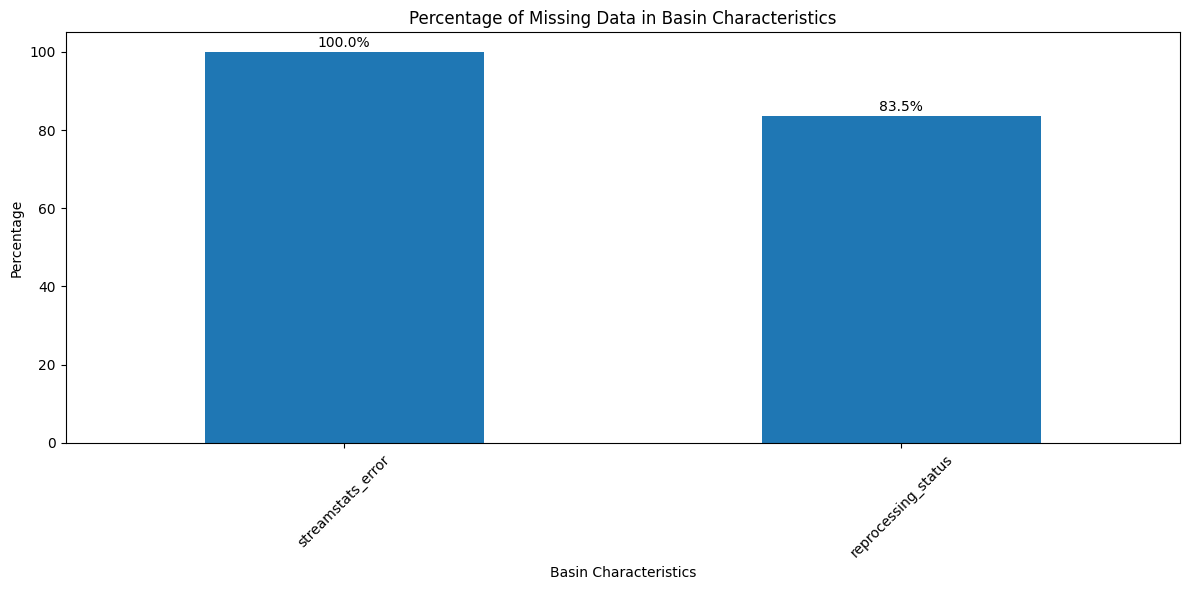

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df_basin = pd.read_csv("data/basin_characteristics.csv", dtype=str)
# check and plot percentage of missing data for each column 
missing_data = df_basin.isna().mean() * 100
missing_data = missing_data[missing_data > 0]
missing_data.plot(kind='bar', figsize=(12, 6), title='Percentage of Missing Data in Basin Characteristics')
plt.xlabel('Basin Characteristics')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
#show value of each column
for i, v in enumerate(missing_data):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df_basin = pd.read_csv("data/basin_characteristics.csv", dtype=str)
# drop column streamstats_error or reprocessing_status
df_basin = df_basin.drop(columns=['streamstats_error', 'reprocessing_status'], errors='ignore')
# show row with nan values
len(df_basin)

109

# RAINFALL DATASET

In [4]:
rainfall = pd.read_csv("rainfall_dataset.txt")
rainfall.head()

,Date,Hour,StID,Value
0,12/31/00,19:00,RABCH001,0.0
1,12/31/00,19:00,RABCH002,0.0
2,12/31/00,19:00,RABCH003,0.0
3,12/31/00,19:00,RABCH004,0.0
4,12/31/00,19:00,RABCH005,0.0


In [5]:
rainfall_metadata = pd.read_csv("metadata.csv")
rainfall_metadata.head()

,Beach_ID,Beach_Name,Station_ID,Latitude,Longitude,Abbv_Name
0,1,River Ave.,RABCH001,40.088467,-74.073058,RivAve
1,2,Windward,RABCH002,40.056611,-74.111469,Windward
2,3,Money Island,RABCH003,39.948419,-74.163247,MnyIsnd
3,4,Wreck Pond,RABCH004,40.138382,-74.026131,WrPnd
4,5,Shark River Beach and Yacht Club,RABCH014,40.190758,-74.038703,SRBYC


In [6]:
rainfall_data = rainfall.merge(rainfall_metadata, right_on='Station_ID', left_on='StID', how = "left")
rainfall_data.to_csv("data/rainfall_data.csv", index=False)

In [5]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# --- Configuration ---
DISCHARGE_TS_PATH = "data/usgs_discharge.csv"
BASIN_CHARS_PATH = "data/basin_characteristics.csv"
RAINFALL_TS_PATH = "data/rainfall_data.csv"  
OUTPUT_PATH = "data/rainfall_series.csv"


def get_discharge_sites_with_coords(discharge_path, basin_chars_path):
    """Loads unique discharge sites and merges them with their coordinates."""
    print("Loading discharge site locations...")
    
    # Load basin characteristics to get coordinates
    basin_df = pd.read_csv(basin_chars_path, dtype={'site_no': str})

    # Load discharge data to get the list of relevant sites
    discharge_df = pd.read_csv(discharge_path, dtype={'siteCode': str})
    # Ensure siteCode is string to match basin_df['site_no'] if it's object
    discharge_df['siteCode'] = discharge_df['siteCode'].astype(str)
    basin_df['site_no'] = basin_df['site_no'].astype(str)
    
    unique_discharge_sites = discharge_df['siteCode'].unique()

    # Filter basin characteristics to only include sites present in the discharge data
    site_coords = basin_df[basin_df['site_no'].isin(unique_discharge_sites)]
    
    # Keep only necessary columns and handle potential missing coords
    site_coords = site_coords[['site_no', 'original_lat', 'original_lon']].dropna()
    return site_coords.set_index('site_no')


def load_and_process_rainfall_data(rainfall_path):
    """Loads, cleans, and aggregates hourly rainfall data to daily totals."""
    print("Loading and processing rainfall data...")
    
    rain_df = pd.read_csv(rainfall_path, on_bad_lines='skip', dtype={'StID': str, 'Date': str, 'Hour': str, 'Value': float})

    # --- Date and Time Processing ---
    # Handle the 'MM/DD/YY HH:MM' format
    # The 'YY' format assumes years like '00' are 2000. Add logic if century is ambiguous.
    rain_df['dateTime'] = pd.to_datetime(rain_df['Date'] + ' ' + rain_df['Hour'], 
                                         format='%m/%d/%y %H:%M', errors='coerce')
    rain_df = rain_df.dropna(subset=['dateTime', 'Latitude', 'Longitude', 'Station_ID', 'Value'])

    # --- Aggregate to Daily Data ---
    # Group by date (ignoring time) and station, then sum the rainfall values
    rain_df['date_only'] = rain_df['dateTime'].dt.date
    daily_rain = rain_df.groupby(['date_only', 'Station_ID'])['Value'].sum().reset_index()
    daily_rain['date_only'] = pd.to_datetime(daily_rain['date_only'])
    
    # --- Create Pivot Table ---
    # Rows: dates, Columns: station IDs, Values: daily rainfall
    rainfall_pivot = daily_rain.pivot_table(index='date_only', columns='Station_ID', values='Value', aggfunc='sum')
    
    # --- Get Unique Station Coordinates ---
    station_coords = rain_df[['Station_ID', 'Latitude', 'Longitude']].drop_duplicates('Station_ID').set_index('Station_ID')

    return rainfall_pivot, station_coords


def map_sites_to_stations(discharge_sites, rainfall_stations):
    """Finds the closest rainfall station for each discharge site."""
    print("Mapping discharge sites to nearest rainfall stations...")

    # Use cKDTree for efficient nearest-neighbor search
    # Note: Using lat/lon directly is an approximation. For high accuracy, convert to a projected CRS.
    tree = cKDTree(rainfall_stations[['Latitude', 'Longitude']].values)
    
    # For each discharge site, query the tree to find the index of the closest rainfall station
    dist, indices = tree.query(discharge_sites[['original_lat', 'original_lon']].values, k=1)
    
    # Create the mapping from discharge site ID to the closest rainfall station ID
    closest_station_ids = rainfall_stations.index[indices]
    site_to_station_map = dict(zip(discharge_sites.index, closest_station_ids))
    
    print(f"  Successfully created mapping for {len(site_to_station_map)} sites.")
    return site_to_station_map


discharge_sites_coords = get_discharge_sites_with_coords(DISCHARGE_TS_PATH, BASIN_CHARS_PATH)
discharge_df = pd.read_csv(DISCHARGE_TS_PATH)
discharge_pivot = discharge_df.pivot_table(index='dateTime', columns='siteCode', values='value')
master_time_index = pd.to_datetime(discharge_pivot.index)

rainfall_pivot, rainfall_station_coords = load_and_process_rainfall_data(RAINFALL_TS_PATH)

site_station_map = map_sites_to_stations(discharge_sites_coords, rainfall_station_coords)
print(discharge_sites_coords.index)
aligned_rainfall_df = pd.DataFrame(index=master_time_index, columns=discharge_sites_coords.index)
aligned_rainfall_df.index.name = "dateTime"

for discharge_site, rainfall_station in site_station_map.items():
    if rainfall_station in rainfall_pivot.columns:
        rainfall_series = rainfall_pivot[rainfall_station]
        aligned_rainfall_df[discharge_site] = rainfall_series.reindex(master_time_index)

aligned_rainfall_df = aligned_rainfall_df.fillna(1e-4)

# 5. Save the result
aligned_rainfall_df.to_csv(OUTPUT_PATH)
print(f"\nSuccessfully created aligned rainfall data.")
print(f"Output saved to: {OUTPUT_PATH}")
print("Final data shape:", aligned_rainfall_df.shape)
print("Final data preview:\n", aligned_rainfall_df.head())



Loading discharge site locations...


Loading and processing rainfall data...
Mapping discharge sites to nearest rainfall stations...
  Successfully created mapping for 119 sites.
Index(['01377500', '01378500', '01379000', '01379500', '01379530', '01379780',
       '01379845', '01380450', '01381000', '01381500',
       ...
       '01446000', '01377370', '01389010', '01389890', '01403060', '01403400',
       '01400500', '01387000', '01388500', '01457000'],
      dtype='object', name='site_no', length=119)

Successfully created aligned rainfall data.
Output saved to: data/rainfall_series.csv
Final data shape: (1827, 119)
Final data preview:
 site_no     01377500  01378500  01379000  01379500  01379530  01379780  \
dateTime                                                                 
2020-01-01      0.00      0.00      0.00      0.00      0.00      0.00   
2020-01-02      0.00      0.00      0.00      0.00      0.00      0.00   
2020-01-03      0.20      0.18      0.08      0.09      0.09      0.17   
2020-01-04      0.24

In [6]:
aligned_rainfall_df.describe()

site_no,01377500,01378500,01379000,01379500,01379530,01379780,01379845,01380450,01381000,01381500,...,01446000,01377370,01389010,01389890,01403060,01403400,01400500,01387000,01388500,01457000
count,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,...,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000
mean,0.144264,0.143158,0.147378,0.139688,0.139688,0.133153,0.143662,0.133131,0.133131,0.139568,...,0.140454,0.144264,0.131637,0.143158,0.147893,0.137072,0.152917,0.131418,0.130411,0.141576
std,0.368141,0.378142,0.415813,0.365582,0.365582,0.336771,0.366933,0.343597,0.343597,0.360082,...,0.379501,0.368141,0.336538,0.378142,0.413218,0.374150,0.414062,0.340333,0.331900,0.369296
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.090000,0.090000,0.095000,0.090000,0.090000,0.100000,0.105000,0.090000,0.090000,0.100000,...,0.090000,0.090000,0.090000,0.090000,0.100000,0.090000,0.110000,0.080000,0.080000,0.110000
max,4.320000,6.340000,8.440000,6.300000,6.300000,4.410000,4.590000,4.140000,4.140000,5.440000,...,4.020000,4.320000,4.580000,6.340000,8.780000,7.910000,8.690000,4.540000,3.960000,5.110000
